# Fourier analysis from scratch: hearing the notes inside a signal

This is the first notebook of a three-part series on finding repeating
patterns in time series data. It assumes basic Python with numpy
(pandas joins once real data arrives in notebook 02) and nothing else:
no signal processing background, no complex analysis, no prior meeting
with the FFT. By the end of the series you will be able to take a
messy real-world series (we will use sixty-eight years of atmospheric
CO2 and thirty-three months of hourly traffic), state confidently
which cycles live inside it, defend that claim statistically, and turn
it into a demand baseline a business can plan against.

The plan:

1. **This notebook**: what the Fourier transform actually does, built
   up by hand before any library call, plus the three practical traps
   (sampling, leakage, noise) that catch every beginner.
2. **[Notebook 02](02_seasonality_in_the_keeling_curve.ipynb)**: real
   data. Four different tools hunt the seasonality in the Keeling
   curve, and we make them agree.
3. **[Notebook 03](03_demand_rhythms_and_staffing.ipynb)**: the
   business notebook. Hourly traffic demand, its spectrum, a baseline,
   an anomaly alarm, and capacity arithmetic.

The core idea fits in one sentence. A time series is like a chord
played on a piano: what reaches your ear is one wiggly pressure wave,
yet a trained listener can name the individual notes inside it. The
Fourier transform is that trained listener, for any signal. This
notebook teaches you what it listens *for*, and how.

## Pure tones first

A **sine wave** is the atom of this whole subject, and it has exactly
three knobs:

- **Amplitude**: how tall the wave is, its peak height.
- **Frequency**: how many complete cycles fit into one unit of time,
  measured in cycles per second (hertz, Hz) or cycles per day, per
  year, whatever suits the data.
- **Phase**: where in its cycle the wave is at time zero, whether it
  starts at its peak, at zero on the way up, or anywhere else.

One picture per knob, and the vocabulary is yours.

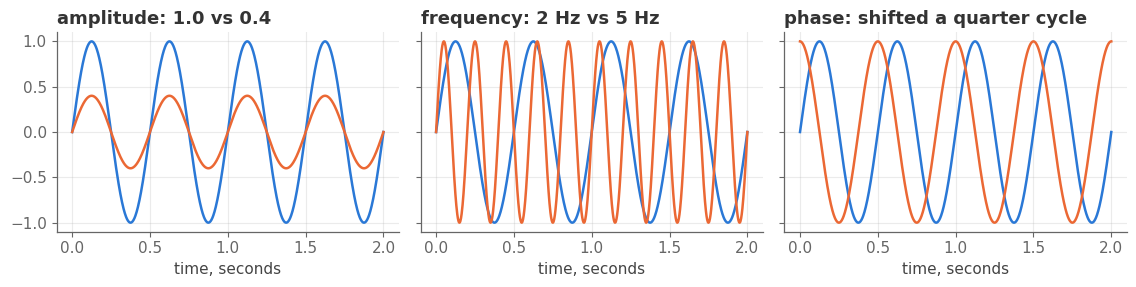

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

BLUE, ORANGE, GREEN = '#2a78d6', '#eb6834', '#1baf7a'
AMBER, RED, GRAY, INK = '#fab219', '#d03b3b', '#8a8f98', '#333333'

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#666666', 'axes.linewidth': 0.9,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold',
    'axes.titlelocation': 'left', 'axes.titlecolor': INK,
    'axes.labelsize': 11, 'axes.labelcolor': '#444444',
    'xtick.color': '#666666', 'ytick.color': '#666666',
    'legend.frameon': False, 'font.size': 11,
})

t = np.linspace(0, 2, 1000)

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.0), sharey=True)
axes[0].plot(t, 1.0 * np.sin(2 * np.pi * 2 * t), color=BLUE, lw=1.8)
axes[0].plot(t, 0.4 * np.sin(2 * np.pi * 2 * t), color=ORANGE, lw=1.8)
axes[0].set_title('amplitude: 1.0 vs 0.4')
axes[1].plot(t, np.sin(2 * np.pi * 2 * t), color=BLUE, lw=1.8)
axes[1].plot(t, np.sin(2 * np.pi * 5 * t), color=ORANGE, lw=1.8)
axes[1].set_title('frequency: 2 Hz vs 5 Hz')
axes[2].plot(t, np.sin(2 * np.pi * 2 * t), color=BLUE, lw=1.8)
axes[2].plot(t, np.sin(2 * np.pi * 2 * t + np.pi / 2), color=ORANGE, lw=1.8)
axes[2].set_title('phase: shifted a quarter cycle')
for ax in axes:
    ax.set_xlabel('time, seconds')
fig.tight_layout()

That quarter-cycle shift in the last panel has a name you already
know: a sine shifted forward by a quarter cycle *is* a cosine. Sine
and cosine are the same wave caught at different moments, so they
will always appear as a pair below.

## Now a chord

Here is the situation Fourier analysis exists for. Take a slow, strong
wave (amplitude 1.0 at 2 Hz) and add a fast, weak one (amplitude 0.5
at 20 Hz). Looking at the ingredients, everything is obvious. Looking
at the sum, the fast wave has become fuzz riding on the slow one, and
if I handed you the sum alone and asked "what exactly is in this?",
eyeballing would get you roughly nowhere. Real data always hands you
the sum alone.

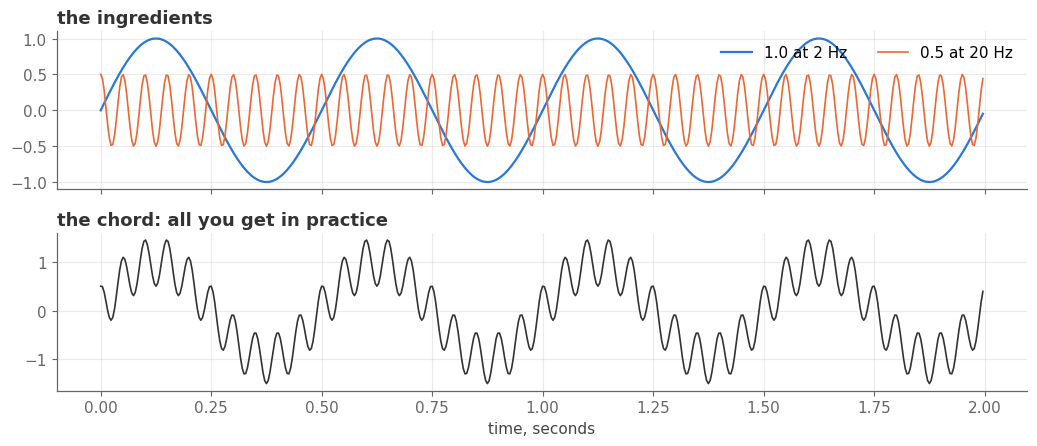

In [2]:
fs = 256                     # samples per second
duration = 2.0
t = np.arange(0, duration, 1 / fs)

slow = 1.0 * np.sin(2 * np.pi * 2 * t)
fast = 0.5 * np.cos(2 * np.pi * 20 * t)
signal = slow + fast

fig, axes = plt.subplots(2, 1, figsize=(10.5, 4.6), sharex=True)
axes[0].plot(t, slow, color=BLUE, lw=1.6, label='1.0 at 2 Hz')
axes[0].plot(t, fast, color=ORANGE, lw=1.2, label='0.5 at 20 Hz')
axes[0].set_title('the ingredients')
axes[0].legend(loc='upper right', ncol=2)
axes[1].plot(t, signal, color=INK, lw=1.2)
axes[1].set_title('the chord: all you get in practice')
axes[1].set_xlabel('time, seconds')
fig.tight_layout()

## Finding the notes by hand

Before any library function, let us build the detector ourselves,
because it is small enough to fit in your head.

**The probe idea.** To test whether a 5 Hz wave hides inside a signal,
multiply the signal, point by point, by a clean 5 Hz wave (a *probe*)
and take the average of the product. Two things can happen:

- If the signal contains a 5 Hz component, it rises when the probe
  rises and falls when the probe falls, so the product is positive
  more than negative, and the average comes out clearly nonzero.
- If it does not, the product's positive and negative patches cancel,
  and the average washes out to roughly zero. For any *other* pure
  frequency that fits a whole number of cycles into the window (a set
  we will meet properly below), the cancellation is exact: waves of
  different frequencies are uncorrelated, which mathematicians call
  orthogonality.

One wrinkle: the hidden wave might be shifted relative to our probe
(remember phase), and a sine probe is blind to a cosine of the same
frequency. The fix is to probe twice, once with a sine and once with a
cosine, and combine the two averages like the two legs of a right
triangle. Multiply by 2 and you recover the amplitude itself.

That is the entire Fourier transform. Everything else is speed and
bookkeeping. Watch it find our chord.

probe at  2 Hz: 1.0000
probe at 20 Hz: 0.5000
probe at 11 Hz: 0.0000


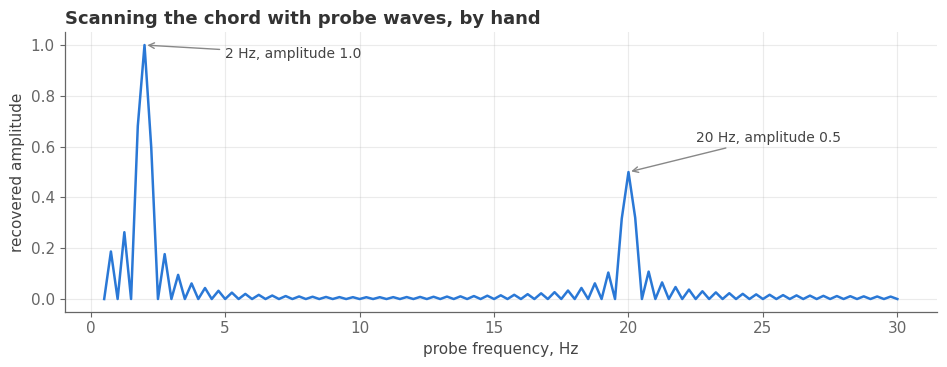

In [3]:
def probe(signal, t, freq):
    """Amplitude of the component of `signal` at `freq`, by correlation."""
    s = np.mean(signal * np.sin(2 * np.pi * freq * t))
    c = np.mean(signal * np.cos(2 * np.pi * freq * t))
    return 2 * np.hypot(s, c)

probe_freqs = np.arange(0.5, 30.25, 0.25)
scan = [probe(signal, t, f) for f in probe_freqs]

fig, ax = plt.subplots(figsize=(9.6, 3.8))
ax.plot(probe_freqs, scan, color=BLUE, lw=1.8)
ax.annotate('2 Hz, amplitude 1.0', xy=(2, 1.0), xytext=(5, 0.95),
            fontsize=10, color='#444444',
            arrowprops=dict(arrowstyle='->', color='#888888'))
ax.annotate('20 Hz, amplitude 0.5', xy=(20, 0.5), xytext=(22.5, 0.62),
            fontsize=10, color='#444444',
            arrowprops=dict(arrowstyle='->', color='#888888'))
ax.set_xlabel('probe frequency, Hz')
ax.set_ylabel('recovered amplitude')
ax.set_title('Scanning the chord with probe waves, by hand')
fig.tight_layout()

print(f"probe at  2 Hz: {probe(signal, t, 2):.4f}")
print(f"probe at 20 Hz: {probe(signal, t, 20):.4f}")
print(f"probe at 11 Hz: {probe(signal, t, 11):.4f}")

Two spikes, at exactly the right frequencies, with exactly the right
amplitudes, and silence at frequencies we never put in. You have just
computed a Fourier transform with four lines of numpy.

## The FFT: the same scan, done properly

Scanning frequency by frequency works but wastes effort. The **fast
Fourier transform** (FFT) computes the entire scan at once, exploiting
shared structure between probe frequencies, in roughly $N \log N$
operations instead of $N^2$. That speedup, published by Cooley and
Tukey in 1965, is the reason spectral analysis is a routine tool
rather than a supercomputer luxury.

Three pieces of bookkeeping, and they are the parts every beginner
trips on, so read them slowly:

1. **Which frequencies come back?** For $N$ samples taken at rate
   $f_s$, you get frequencies from 0 up to $f_s / 2$, spaced
   $1 / \text{duration}$ apart. `np.fft.rfftfreq(N, d=1/fs)` builds
   this grid for you; never build it by hand.
2. **The "r" in `rfft`.** For real-valued data (all data in this
   series), the negative-frequency half of the full transform is a
   mirror image carrying no new information, so `rfft` returns only
   the useful half.
3. **Normalization.** `rfft` returns raw correlation sums, not
   amplitudes. To read amplitudes, divide by $N$ and multiply by 2
   (the factor 2 folds in the discarded mirror half; it does not apply
   to the 0 Hz term, nor to the $f_s/2$ term when $N$ is even, since
   neither has a mirror copy). Libraries disagree on conventions, so
   we verify against a case where we know the answer.

FFT amplitude at  2 Hz: 1.0000
FFT amplitude at 20 Hz: 0.5000


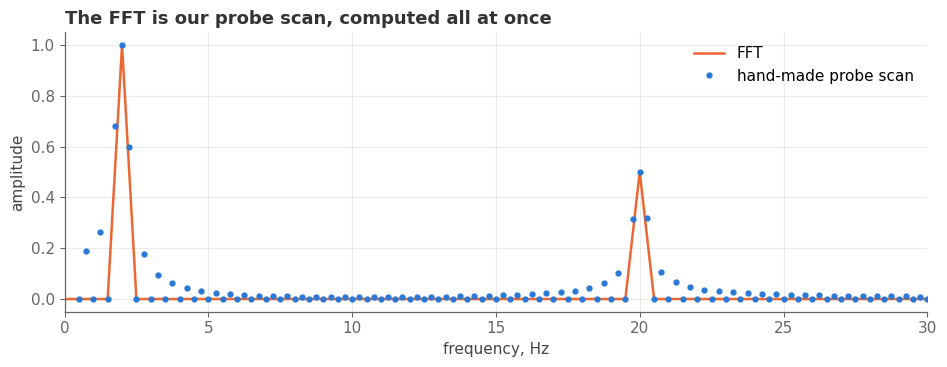

In [4]:
from numpy.fft import rfft, rfftfreq

spectrum = np.abs(rfft(signal)) * 2 / len(signal)
freqs = rfftfreq(len(signal), d=1 / fs)

fig, ax = plt.subplots(figsize=(9.6, 3.8))
ax.plot(freqs, spectrum, color=ORANGE, lw=1.8, label='FFT')
ax.plot(probe_freqs, scan, color=BLUE, lw=0, marker='o', ms=3.5,
        label='hand-made probe scan')
ax.set_xlim(0, 30)
ax.set_xlabel('frequency, Hz')
ax.set_ylabel('amplitude')
ax.set_title('The FFT is our probe scan, computed all at once')
ax.legend()
fig.tight_layout()

i2 = np.argmin(np.abs(freqs - 2))
i20 = np.argmin(np.abs(freqs - 20))
print(f"FFT amplitude at  2 Hz: {spectrum[i2]:.4f}")
print(f"FFT amplitude at 20 Hz: {spectrum[i20]:.4f}")
assert np.isclose(spectrum[i2], 1.0, atol=1e-9)
assert np.isclose(spectrum[i20], 0.5, atol=1e-9)

Wherever the two computations share a frequency, they agree, and the
asserts pin the amplitudes to the truth we built in. Throughout this
series, whenever a number matters, we will get it twice by routes that
cannot share a bug; this was the first instance.

Look closely and the overlay teaches a bonus lesson: between the
FFT's grid points, our hand scan shows little skirts of nonzero
amplitude that the FFT line does not have. Those probe frequencies do
not fit a whole number of cycles into our two-second window, and a
partial cycle cannot cancel cleanly. Hold that thought; it has a name,
and a section below.

The FFT also returns what our amplitude plot throws away: **phase**,
the shift of each component. It lives in the complex angle of each
FFT value. We will not need phase for seasonality hunting, but you
should see it once, if only to stop fearing the complex numbers.

In [5]:
z = rfft(signal)
print(f"phase at  2 Hz: {np.degrees(np.angle(z[i2])):7.1f} degrees  "
      f"(a sine lags a cosine by 90)")
print(f"phase at 20 Hz: {np.degrees(np.angle(z[i20])):7.1f} degrees  "
      f"(we used a cosine: zero shift)")

phase at  2 Hz:   -90.0 degrees  (a sine lags a cosine by 90)
phase at 20 Hz:    -0.0 degrees  (we used a cosine: zero shift)


## Trap one: sampling too slowly

Real data is sampled: monthly readings, hourly counts. Sampling has a
speed limit, and violating it does not produce an error message. It
produces a confident, wrong answer, which is far more dangerous.

To capture a wave, you need at least two samples per cycle, so a
sampling rate $f_s$ can only see frequencies up to $f_s / 2$, the
**Nyquist frequency**. Sample a faster wave and it does not vanish: it
masquerades as a slower one, a phenomenon called **aliasing**. You
have watched this happen: wagon wheels in old westerns spinning
slowly backward because the camera's 24 frames per second cannot keep
up with the spokes.

Here is our 20 Hz wave sampled at 15 samples per second, well under
the 40 it needs. The sparse samples trace out a perfectly convincing
5 Hz wave.

the spectrum of the samples peaks at 5.0 Hz, and it is lying


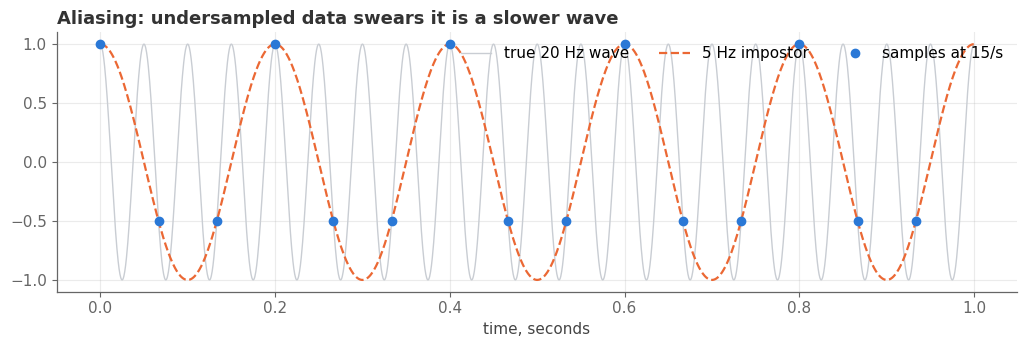

In [6]:
t_dense = np.arange(0, 1, 1 / 2000)
wave = np.cos(2 * np.pi * 20 * t_dense)

fs_slow = 15
t_slow = np.arange(0, 1, 1 / fs_slow)
samples = np.cos(2 * np.pi * 20 * t_slow)
alias = np.cos(2 * np.pi * 5 * t_dense)      # 20 - 15 = 5 Hz impostor

fig, ax = plt.subplots(figsize=(10.5, 3.6))
ax.plot(t_dense, wave, color='#c9cdd3', lw=1.0, label='true 20 Hz wave')
ax.plot(t_dense, alias, color=ORANGE, lw=1.6, ls='--',
        label='5 Hz impostor')
ax.plot(t_slow, samples, 'o', color=BLUE, ms=6, label='samples at 15/s')
ax.set_xlabel('time, seconds')
ax.set_title('Aliasing: undersampled data swears it is a slower wave')
ax.legend(loc='upper right', ncol=3)
fig.tight_layout()

spec_slow = np.abs(rfft(samples)) * 2 / len(samples)
freq_slow = rfftfreq(len(samples), d=1 / fs_slow)
print(f"the spectrum of the samples peaks at "
      f"{freq_slow[np.argmax(spec_slow)]:.1f} Hz, and it is lying")

The impostor's identity is predictable, not random: it appears at
the distance between the true frequency and the nearest multiple of
the sampling rate, here 20 - 15 = 5 Hz. The defense is knowing your
sampling rate and refusing to interpret anything at or beyond half of
it. Monthly data cannot testify about
cycles shorter than two months; hourly data is silent about anything
under two hours. Aliasing is also why notebook 03 will be careful
about what hourly traffic data can and cannot say.

## Trap two: leakage, and windows

The FFT quietly assumes your recording repeats forever, end glued to
start. If the recording contains a whole number of cycles, the glue
joint is seamless. If it contains, say, 8.5 cycles, the joint has a
kink, and the FFT explains that kink the only way it can: by smearing
energy into the neighboring points of its frequency grid (each grid
point is called a **bin**). The smear is called **spectral leakage**,
and it can bury a weak second peak entirely.

The standard remedy is a **window**: taper the recording so it fades
in from zero and out to zero, which removes the kink at the cost of a
slightly wider peak. The taper we will use, a raised cosine called the
Hann window, is the sensible default in almost every situation. (When
a window changes the answer *a lot*, that itself is information: your
record probably holds partial cycles of something slow, a lesson that
returns with the trend in notebook 02.)

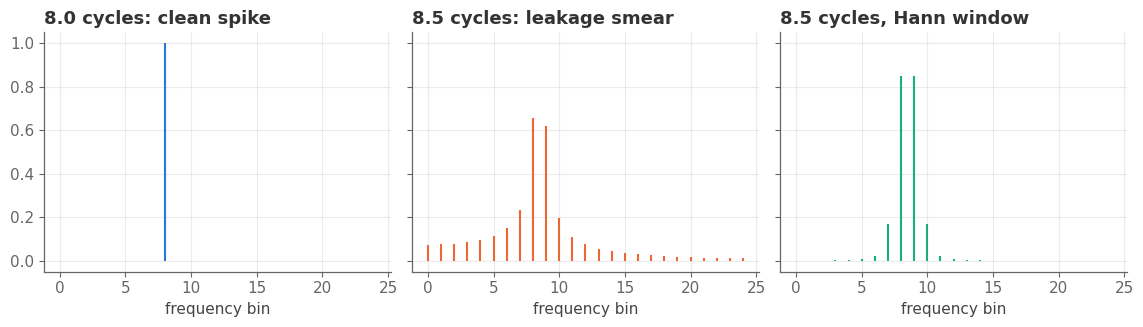

In [7]:
n_show = 512
t8 = np.arange(n_show) / n_show
whole = np.sin(2 * np.pi * 8 * t8)           # exactly 8 cycles
partial = np.sin(2 * np.pi * 8.5 * t8)       # 8.5 cycles: kink at the joint
hann = np.hanning(n_show)

def amp_spectrum(x, window=None):
    if window is None:
        return np.abs(rfft(x)) * 2 / len(x)
    return np.abs(rfft(x * window)) * 2 / window.sum()

k = np.arange(0, 25)
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.4), sharey=True)
axes[0].stem(k, amp_spectrum(whole)[:25], basefmt=' ',
             linefmt=BLUE, markerfmt=' ')
axes[0].set_title('8.0 cycles: clean spike')
axes[1].stem(k, amp_spectrum(partial)[:25], basefmt=' ',
             linefmt=ORANGE, markerfmt=' ')
axes[1].set_title('8.5 cycles: leakage smear')
axes[2].stem(k, amp_spectrum(partial, hann)[:25], basefmt=' ',
             linefmt=GREEN, markerfmt=' ')
axes[2].set_title('8.5 cycles, Hann window')
for ax in axes:
    ax.set_xlabel('frequency bin')
fig.tight_layout()

Middle panel: the single frequency has leaked into a skirt a dozen
bins wide. Right panel: the window pulls the skirt back in, and the
peak sits at bin 8 to 9, as close to 8.5 as a discrete grid can say.
Note the normalization changed too: with a window you divide by the
window's sum, not by $N$, to keep amplitudes honest.

## Trap three: noise, and why the FFT shrugs at it

Last trap, with a happy ending. Real signals come buried in noise,
often noise much larger than the signal. The probe logic explains why
that is survivable: noise is uncorrelated with *every* probe, so its
contributions average toward zero across the whole record, while a
true periodic component adds up coherently, sample after sample. The
longer the record, the better the averaging works.

Here is a 7 Hz wave of amplitude 0.5 drowned in noise four times its
size. The eye sees nothing. The spectrum barely notices the
difficulty.

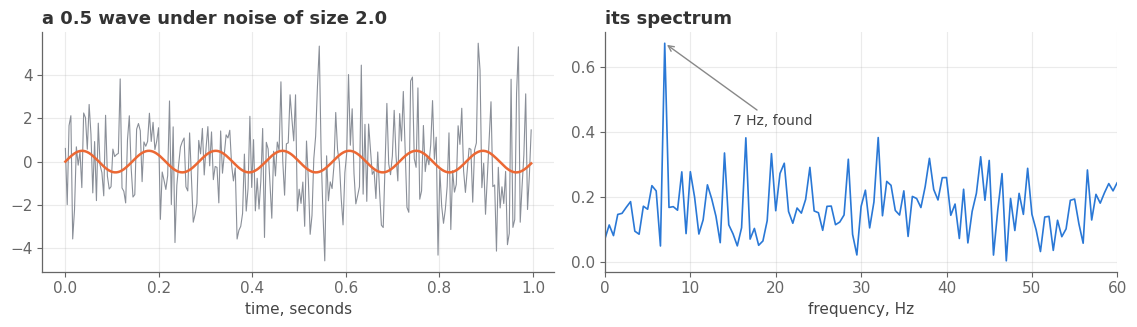

In [8]:
rng = np.random.default_rng(42)
clean = 0.5 * np.sin(2 * np.pi * 7 * t)
noisy = clean + rng.normal(0, 2.0, len(t))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.4))
axes[0].plot(t[:256], noisy[:256], color=GRAY, lw=0.8)
axes[0].plot(t[:256], clean[:256], color=ORANGE, lw=1.8)
axes[0].set_title('a 0.5 wave under noise of size 2.0')
axes[0].set_xlabel('time, seconds')
spec_n = np.abs(rfft(noisy)) * 2 / len(noisy)
axes[1].plot(freqs, spec_n, color=BLUE, lw=1.2)
axes[1].annotate('7 Hz, found', xy=(7, spec_n[np.argmin(np.abs(freqs - 7))]),
                 xytext=(15, 0.42), fontsize=10, color='#444444',
                 arrowprops=dict(arrowstyle='->', color='#888888'))
axes[1].set_xlim(0, 60)
axes[1].set_title('its spectrum')
axes[1].set_xlabel('frequency, Hz')
fig.tight_layout()

The peak stands clear of the noise floor. How clear a peak has to be
before you should believe it is a real question with a real answer,
and notebook 02 answers it with a permutation test rather than a rule
of thumb.

## Vocabulary, in plain words

| Term | Plain meaning |
|------|---------------|
| amplitude | the height of a wave; in data units |
| frequency | cycles per unit time; period is its reciprocal |
| phase | where in its cycle a wave sits at time zero |
| spectrum | recovered amplitude at every frequency; the probe scan |
| FFT / `rfft` | the fast algorithm computing that scan; `r` = for real-valued data |
| Nyquist frequency | half the sampling rate; the fastest wave your samples can testify about |
| aliasing | an undersampled fast wave impersonating a slow one |
| spectral leakage | smearing caused by partial cycles at the record's edges |
| window (Hann) | a taper that trades a slightly wider peak for far less leakage |

## Takeaways

1. The Fourier transform is correlation with probe waves, nothing
   more. You built it by hand in four lines, and the FFT matched it
   to machine precision.
2. Amplitude comes with bookkeeping (2/N, or 2/sum of the window),
   and the way to trust your bookkeeping is a test case with a known
   answer.
3. The three traps are sampling (respect Nyquist), leakage (window
   your data), and noise (mostly harmless, but demands a significance
   check before you believe a peak).

Notebook 02 takes this toolkit to sixty-eight years of real
atmospheric data, where the raw FFT stumbles immediately, for a
reason no synthetic example above prepared you for.

---

*Satsawat Natakarnkitkul · [satsawat.ai](https://satsawat.ai) ·
[AI in Practice newsletter](https://satsawat.ai/#newsletter)*